In [38]:
'''
This file is a first attempt to create some custom BMs 
based on the D-Wave Zephyr Graph architecture. 

As of 08/12/2025: 
What has been done: 
Mainly: 
- Generate Zephyr graph
- Assign visible & hidden nodes in the graph 
- Train the resulting BM

Also: 
- Removal of some poorly connected nodes in the graph
- Visualizations: Visible vs Hidden in Zephyr graph 

All this is using the previous functionalities from 
custom_bm.py, which implements the custom architecture 
BMs and handles the PCD, sampling, etc 
--> Improvements there make improvements here! 


To do: 
- Need a meaningful assignment of visible nodes to 
pixels in the image. Right now, it's just the order of labels in 
the graph nodes with order of pixel labels. 
    Probably: Group closeby pixels together somehow
- Speed things up (in custom_BMs, probably)
    --> GPU? 
    --> Faster Gibbs sampling (e.g. with Julia?)
    --> Partition the graph for block Gibbs sampling? 
        - Maybe just need to partition Zephyr graph once...
- Hyperparameter tuning (issue: it's slow to run)
    - Right now no images are looking good at all! 
    - Tune things to get good values. 


'''

'''
8/17/25

Tried assigning pixels to nodes in a way that preserves locality.
Instead of first 144 visible, I tried to group nearby pixels together using degrees of each node.

Also, trained using more gibbs step in training (5 -> 10), more epochs (20 -> 50 -> 100), 
'''

'''
8/24/25

Experimented with different assignments for visible. Specifically:
-> assigning second half as visible, and then using the 12x12 grid 
->  removing node relabling after node removal resulted
-> (*the first time I removed node relabling, and assigned second half as visible (no other changes), there was
        weirdly massive improvement in training (PCD ~0), and the samples looked better as well.
         Have been trying to figure out why it happened for just that run, and replicate it for now but no luck :(

8/30/25

Pre-emptive tuning (esp. lower learning rate) to get a decreasing avg PCD loss, which was a success but the quality of samples degraded.
I believe it was an overfitting issue then. 
'''

'''
9/07/25

Integrated downsizing to variable grid_shapes (e.g. 12x12, 13x13, etc.) !

9/15/25
Added a new complete jupyter notebook for Zephyr BMs with variable grid shapes. 
Ran some tests with different grid shapes and K=3,4,5,6 for the Zephyr graph.


9/21/25
Added fusion of hidden nodes for better mixing. Not fully tested yet, but fusion seems to be working to some extent.


9/22/25
Added targeted reduction of hidden nodes 
'''

'''
10/03/25
Changed the logic for fusing hidden nodes. Now, it uses contracted_nodes from networkx to merge low-degree neighboring hidden nodes.
Improvement in training and quality of samples.
'''

import dwave_networkx as dnx
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.transform import resize
import pandas as pd
import os
from torchvision import datasets, transforms
import bolmaqua as bq


# Set default device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
np.random.seed(42)
random.seed(42)

# --- Config ---
GRID_SHAPE = (12,12)   # <-- change this to (12,12), (13,13), (14,14), etc.
num_visible = GRID_SHAPE[0] * GRID_SHAPE[1]
NUM_VISIBLE = num_visible  # for consistency with other files
grid_shape = GRID_SHAPE  # to be used in other files




Loading dataset...
Found existing ./mnist12x12_trainfeats.npy and ./mnist12x12_trainlabels.npy.
Found existing ./mnist12x12_testfeats.npy and ./mnist12x12_testlabels.npy.
After flattening, X_data shape: torch.Size([1000, 144])


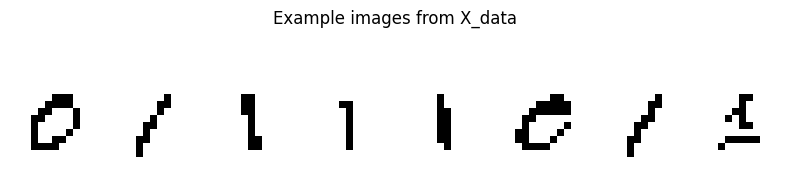

In [39]:

# --- Dataset Loading ---
print("Loading dataset...")
try:
    mnist_feats, mnist_labels = bq.generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE)
except FileNotFoundError as e:
    print("Error: Could not find MNIST CSVs. Falling back to synthetic data...")
    mnist_feats = np.random.rand(1000, NUM_VISIBLE) > 0.3
    mnist_feats = mnist_feats.astype(np.float32)
    mnist_labels = np.zeros(len(mnist_feats), dtype=np.float32)


# Only keep images with label 0 or 1
mnist_feats = mnist_feats[(mnist_labels == 0) | (mnist_labels == 1)]
mnist_labels = mnist_labels[(mnist_labels == 0) | (mnist_labels == 1)]


#cut size of dataset massively for faster training
#PK: Increased this quite a bit, we can just use more data and do less epochs at least 
num_images_to_use = 1000
mnist_feats = mnist_feats[:num_images_to_use]  # Use only the first few images for quick testing
mnist_feats = (mnist_feats - mnist_feats.min()) / (mnist_feats.max() - mnist_feats.min())
# Binarize and create DataLoader
roundup_boost = 0
X_data = (torch.from_numpy(mnist_feats).float() < 0.5 + roundup_boost).float()
# Flatten from (N, 13, 13) → (N, 169)
if X_data.ndim == 3:
    X_data = X_data.view(X_data.shape[0], -1)

# Make sure shape is (num_samples, 169)
print("After flattening, X_data shape:", X_data.shape)

# Add labels explicitly, even if dummy, to avoid 1-tuple nesting
dummy_labels = torch.zeros(len(X_data))  
dataset = torch.utils.data.TensorDataset(X_data, dummy_labels)

# --- Visualize a few images from X_data ---
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_data[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle("Example images from X_data")
plt.tight_layout()
plt.show()

K = 3 n = 336 n/K = 112.0 n/(32*K^2) = 1.0
336


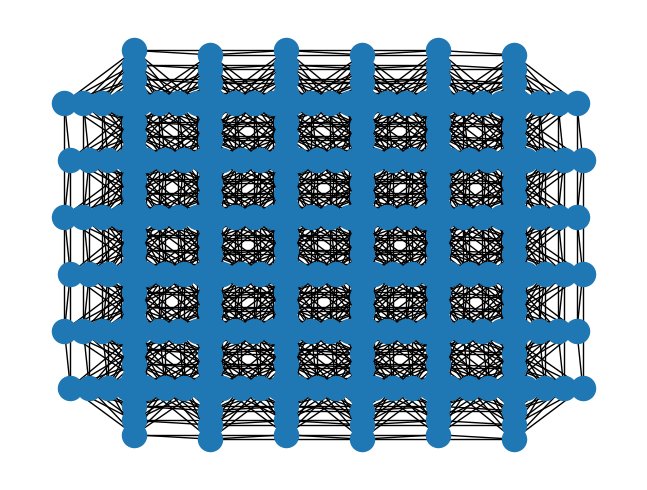

In [40]:
# Helper functions
# Get 2D positions for Zephyr nodes (Zephyr layout)

K = 3
G = dnx.zephyr_graph(K)
n = G.number_of_nodes()
print('K =', K, 'n =', n, 'n/K =', n/K, 
      'n/(32*K^2) =', n/(32*K**2+16*K))

dnx.draw_zephyr(G)
print(G.number_of_nodes())

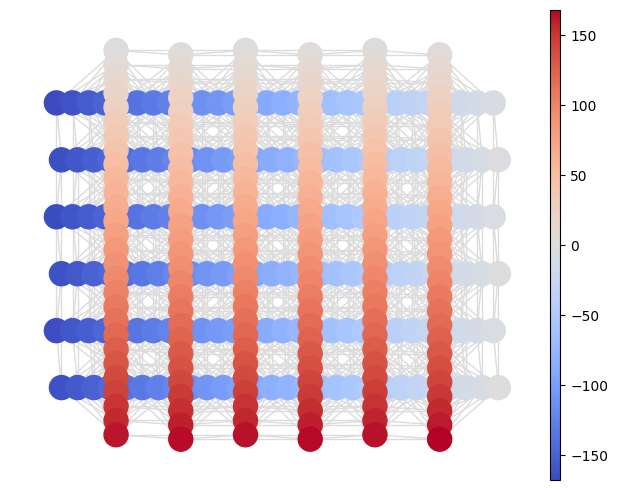

In [41]:
#visualize labelling
#label all the nodes in the graph as visible 1 or hidden 0 
n = G.number_of_nodes()
lin_biases = {i: (i-n/2) for i in range(n)}

dnx.draw_zephyr(G, linear_biases=lin_biases)

In [42]:
#label all the nodes in the graph as visible 1 or hidden 0 
n = G.number_of_nodes()
vh_nodearray = np.zeros(n, dtype=int) 

vh_nodearray[:NUM_VISIBLE] = 1  # first half as visible
node_labels = {i: 'visible' if i < NUM_VISIBLE else 'hidden' for i in range(n)}

print(vh_nodearray)

NUM_HIDDEN = n-NUM_VISIBLE
print('Number of nodes:', n)
print('Number of visibles:', NUM_VISIBLE)
print('Number of hiddens:', NUM_HIDDEN)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]
Number of nodes: 336
Number of visibles: 144
Number of hiddens: 192


dict_items([('zephyr_index', (1, 6, 3, 1, 2)), ('layer', 'hidden')])
Hidden index map: {144: 0, 145: 1, 146: 2, 147: 3, 148: 4, 149: 5, 150: 6, 151: 7, 152: 8, 153: 9, 154: 10, 155: 11, 156: 12, 157: 13, 158: 14, 159: 15, 160: 16, 161: 17, 162: 18, 163: 19, 164: 20, 165: 21, 166: 22, 167: 23, 168: 24, 169: 25, 170: 26, 171: 27, 172: 28, 173: 29, 174: 30, 175: 31, 176: 32, 177: 33, 178: 34, 179: 35, 180: 36, 181: 37, 182: 38, 183: 39, 184: 40, 185: 41, 186: 42, 187: 43, 188: 44, 189: 45, 190: 46, 191: 47, 192: 48, 193: 49, 194: 50, 195: 51, 196: 52, 197: 53, 198: 54, 199: 55, 200: 56, 201: 57, 202: 58, 203: 59, 204: 60, 205: 61, 206: 62, 207: 63, 208: 64, 209: 65, 210: 66, 211: 67, 212: 68, 213: 69, 214: 70, 215: 71, 216: 72, 217: 73, 218: 74, 219: 75, 220: 76, 221: 77, 222: 78, 223: 79, 224: 80, 225: 81, 226: 82, 227: 83, 228: 84, 229: 85, 230: 86, 231: 87, 232: 88, 233: 89, 234: 90, 235: 91, 236: 92, 237: 93, 238: 94, 239: 95, 240: 96, 241: 97, 242: 98, 243: 99, 244: 100, 245: 101, 24

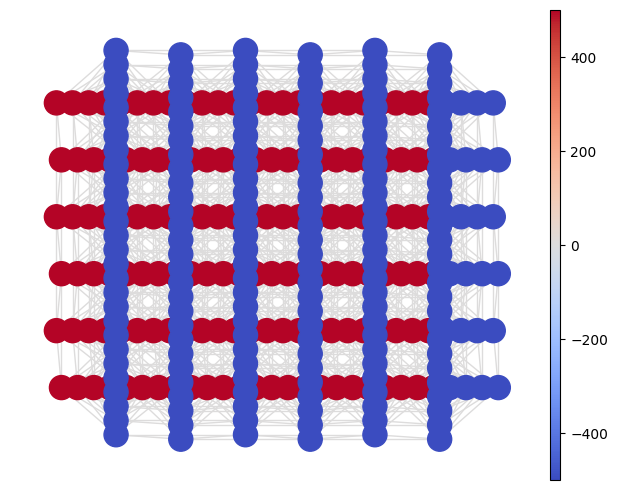

In [43]:
# Example: visibles first, hiddens after
for v in range(num_visible):
    G.nodes[v]["layer"] = "visible"

for h in range(num_visible, num_visible + NUM_HIDDEN):
    G.nodes[h]["layer"] = "hidden"

print(G.nodes[h].items())

hidden_nodes = [n for n in G.nodes if G.nodes[n]["layer"] == "hidden"]
hidden_index_map = {node_id: idx for idx, node_id in enumerate(hidden_nodes)}
print("Hidden index map:", hidden_index_map)

bq.draw_zephyr_hidden_visible(G, vh_nodearray)

In [44]:

# Remove nodes from G (may need to change how this is done)
#Note this is temporary to work around having too many nodes for this dataset

# TEST HERE TO CHANGE TARGET NODES !!
# Remove nodes from G if it has more visibles than our target
final_num_vis = NUM_VISIBLE  # <--  matches GRID_SHAPE automatically
vis_to_remove = NUM_VISIBLE- final_num_vis   

if vis_to_remove > 0:
    # Remove nodes alternately from the start and end of the node list
    to_remove = []
    for i in range(vis_to_remove):
        if i % 2 == 0:
            to_remove.append(visible_nodes[i])
        else:
            to_remove.append(visible_nodes[-i])
    G.remove_nodes_from(to_remove)
    print(f"Removed {vis_to_remove} visible nodes to match target {final_num_vis}")


In [45]:
'''
Next is a very specific way of removing some nodes. 
Namely, these nodes (0 to 4K, n/2-4K to n/2+4K, and n-4K to n) 
are poorly connected (they are on the "edge" of the chip / graph)

'''
nodes_to_remove = np.array([], dtype = 'int')
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(0, 4*K)))
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(round(n/2)-4*K, round(n/2)+4*K)))
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(n-4*K, n)))

G.remove_nodes_from(nodes_to_remove)

# Relabel nodes to go from 0 to (new number of nodes - 1)
G = nx.convert_node_labels_to_integers(G, ordering='sorted')

In [46]:
nodes_sorted = np.array(sorted(G.nodes()), dtype=int)
print("Nodes after removal:", nodes_sorted)

Nodes after removal: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 2

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Updated number of visibles: 144
Updated number of hiddens: 144


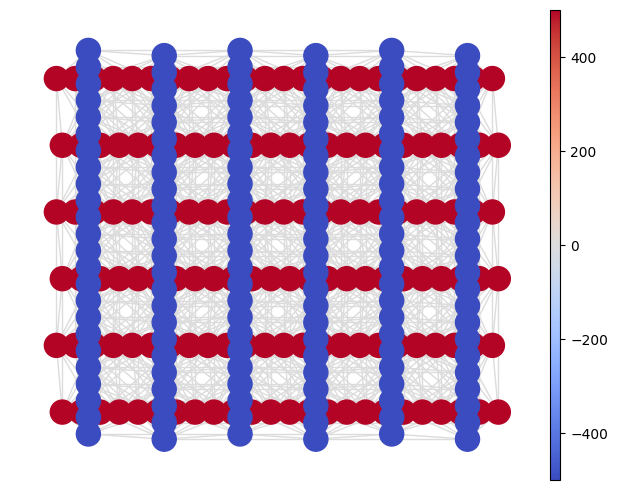

In [47]:
# Build vh_nodearray and node_labels consistent with your downstream code
n = G.number_of_nodes()
NUM_HIDDEN = n - NUM_VISIBLE
vh_nodearray = np.zeros(n, dtype=int)
vh_nodearray[:NUM_VISIBLE] = 1  # first half as visible
node_labels = {i: 'visible' if i < NUM_VISIBLE else 'hidden' for i in range(n)}
print(vh_nodearray)

# print stats
print('Updated number of visibles:', NUM_VISIBLE)
print('Updated number of hiddens:', NUM_HIDDEN)

bq.draw_zephyr_hidden_visible(G, vh_nodearray)   

In [48]:
visible_nodes_in_pixel_order = bq.assign_visibles_by_grid(G, grid_shape=GRID_SHAPE, min_degree=5)  # min_degree optional
assert len(visible_nodes_in_pixel_order) == NUM_VISIBLE
# Relabel so visibles are 0..143 in pixel (row-major) order and then hiddens after that
G, mapping_old_to_new = bq.relabel_visible_first(G, visible_nodes_in_pixel_order) # removing this resulted in massive improvement in training

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Updated number of visibles: 144
Updated number of hiddens: 144
Graph has 288 nodes and 2368 edges
V-V edges: 562, H-H edges: 698, V-H edges: 1108


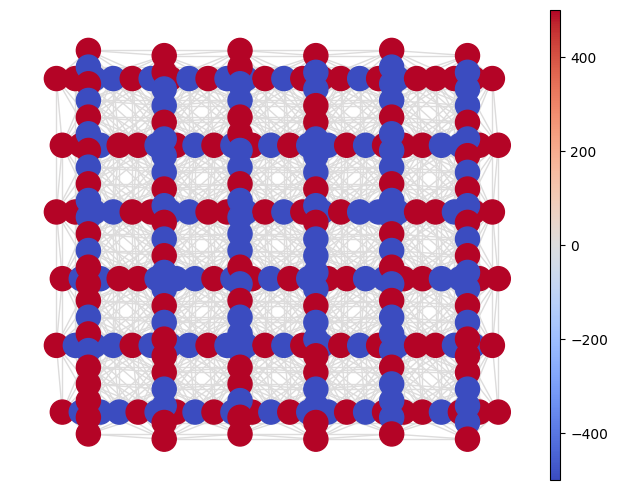

In [49]:
# Build vh_nodearray and node_labels consistent with your downstream code
n = G.number_of_nodes()
NUM_HIDDEN = n - NUM_VISIBLE
vh_nodearray = np.zeros(n, dtype=int)
vh_nodearray[:NUM_VISIBLE] = 1  # first half as visible
node_labels = {i: 'visible' if i < NUM_VISIBLE else 'hidden' for i in range(n)}
print(vh_nodearray)

# print stats
print('Updated number of visibles:', NUM_VISIBLE)
print('Updated number of hiddens:', NUM_HIDDEN)

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")



bq.draw_zephyr_hidden_visible(G, vh_nodearray)    

In [50]:
# Pruning hidden nodes if needed (optional)
# def prune_hidden_nodes(G, target_hidden):
#     # assume visibles are 0..NUM_VISIBLE-1 and hidden start at NUM_VISIBLE
#     hidden = [n for n in sorted(G.nodes()) if n >= NUM_VISIBLE]
#     keep = set(sorted(hidden, key=lambda n: G.degree(n), reverse=True)[:target_hidden])
#     to_remove = [n for n in hidden if n not in keep]
#     G2 = G.copy()
#     G2.remove_nodes_from(to_remove)
#     G2 = nx.convert_node_labels_to_integers(G2, ordering='sorted')
#     return G2

# # Example: keep 64 hidden nodes
# target_hidden = 96
# G = prune_hidden_nodes(G, target_hidden)


# Build vh_nodearray and node_labels
# n = G.number_of_nodes()
# NUM_VISIBLE = GRID_SHAPE[0] * GRID_SHAPE[1]  # This should be 169 for 13x13
# NUM_HIDDEN = n - NUM_VISIBLE
# vh_nodearray = np.zeros(n, dtype=int)
# vh_nodearray[:NUM_VISIBLE] = 1  # visibles are indices 0..143 now
# node_labels = {i: 'visible' if i < NUM_VISIBLE else 'hidden' for i in range(n)}

# # print stats
# print('Updated number of visibles:', NUM_VISIBLE)
# print('Updated number of hiddens:', NUM_HIDDEN)

In [51]:
for v in range(NUM_VISIBLE):
    G.nodes[v]["layer"] = "visible"

for h in range(NUM_VISIBLE, NUM_VISIBLE + NUM_HIDDEN):
    G.nodes[h]["layer"] = "hidden"


hidden_nodes = [n for n in G.nodes if G.nodes[n]["layer"] == "hidden"]
hidden_index_map = {node_id: idx for idx, node_id in enumerate(hidden_nodes)}
print("Hidden nodes:", hidden_nodes)
print("Hidden index map:", hidden_index_map)

Hidden nodes: [144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287]
Hidden index map: {144: 0, 145: 1, 146: 2, 147: 3, 148: 4, 149: 5, 150: 6, 151: 7, 152: 8, 153: 9, 154: 10, 155: 11, 156: 12, 157: 13, 158: 14, 159: 15, 160: 16, 161: 17, 162: 18, 163: 19, 164: 20, 165: 21, 166: 22, 167: 23, 168: 24, 169: 25, 170: 26, 171: 27, 172:

In [52]:
print("Hidden nodes with layer=hidden:", len(hidden_nodes))

for n in hidden_nodes[:10]:
    print(n, "degree:", G.degree(n))

Hidden nodes with layer=hidden: 144
144 degree: 11
145 degree: 12
146 degree: 8
147 degree: 14
148 degree: 20
149 degree: 19
150 degree: 19
151 degree: 20
152 degree: 14
153 degree: 14


In [53]:
# FUSION STEP 
target_hidden =  16
G, hidden_nodes = bq.fuse_hidden_nodes(G, hidden_nodes, target_hidden)
NUM_HIDDEN = len(hidden_nodes)
n = G.number_of_nodes()


In [54]:
print(len(hidden_nodes))


16


Updated number of visibles: 144
Updated number of hiddens: 16
Graph has 160 nodes and 1312 edges
V-V edges: 562, H-H edges: 93, V-H edges: 657


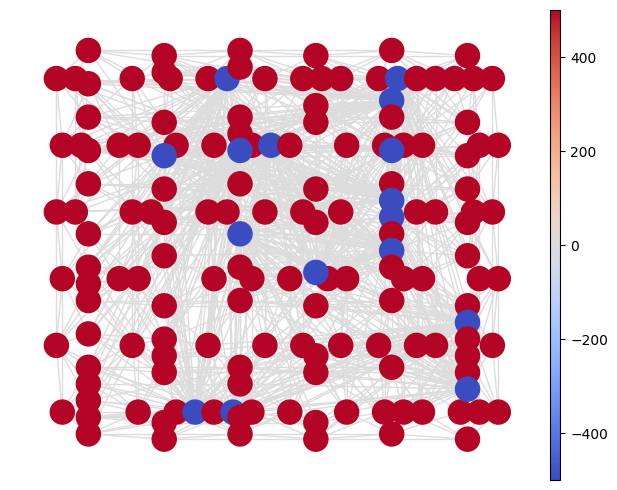

In [55]:
# print stats
print('Updated number of visibles:', NUM_VISIBLE)
print('Updated number of hiddens:', NUM_HIDDEN)

# Build vh_nodearray and node_labels
n = G.number_of_nodes()
NUM_VISIBLE = GRID_SHAPE[0] * GRID_SHAPE[1]  # This should be 169 for 13x13
NUM_HIDDEN = n - NUM_VISIBLE
vh_nodearray = np.zeros(n, dtype=int)
vh_nodearray[:NUM_VISIBLE] = 1  # visibles are indices 0..143 now
node_labels = {i: 'visible' if i < NUM_VISIBLE else 'hidden' for i in range(n)}


print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

bq.draw_zephyr_hidden_visible(G, vh_nodearray)     

In [56]:
# function to find low degree hidden node pairs to fuse
# def select_low_degree_hidden_nodes(G, max_degree, num_pairs, hidden_nodes):
#     """
#     Pick pairs of low-degree hidden nodes to fuse.
#     """
#     low_degree_nodes = [n for n in hidden_nodes if G.degree(n) <= max_degree]

#     fused_pairs = []
#     while len(low_degree_nodes) >= 2 and len(fused_pairs) < num_pairs:
#         i = low_degree_nodes.pop(0)
#         j = low_degree_nodes.pop(0)
#         fused_pairs.append((i, j))
#         print(f"Fusing nodes: {i}, {j}")
#     print(f"Final fused pairs: {fused_pairs}")

#     return fused_pairs

# def remap_fused_pairs(fused_pairs, hidden_index_map):
#     remapped = []
#     for i, j in fused_pairs:
#         if i in hidden_index_map and j in hidden_index_map:
#             remapped.append((hidden_index_map[i], hidden_index_map[j]))
#     print("Fusion pairs remapped:", remapped)
#     return remapped


# fused_pairs = select_low_degree_hidden_nodes(G, max_degree=16, num_pairs=10, hidden_nodes=hidden_nodes)

# fused_pairs_remapped = remap_fused_pairs(fused_pairs, hidden_index_map)
# fused_pairs = fused_pairs_remapped


Graph has 160 nodes and 1312 edges
V-V edges: 562, H-H edges: 93, V-H edges: 657


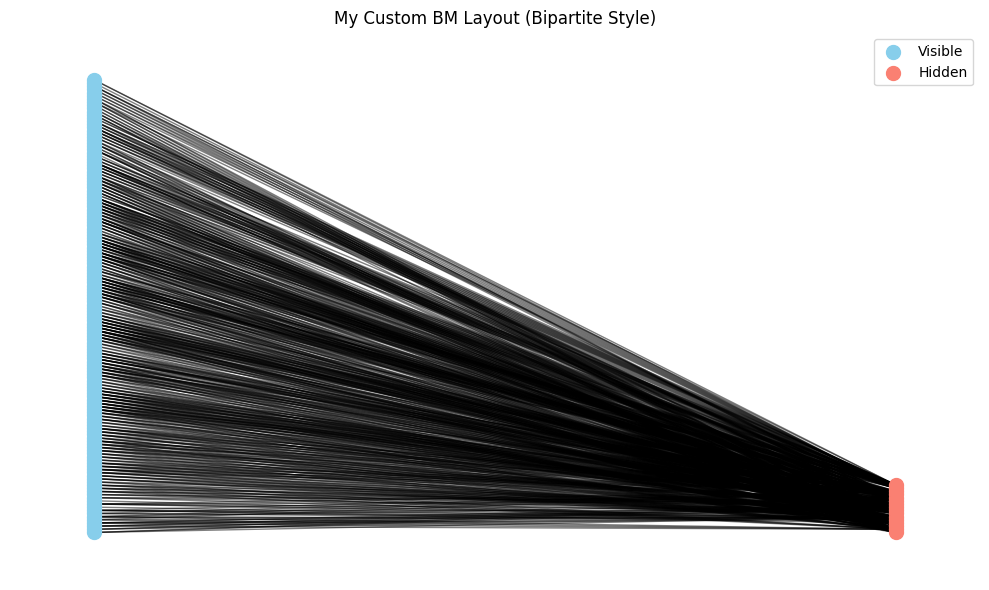

Building Boltzmann Machine from graph... 🏗️
Sanity check:
  dataset feature dim: 144
  model num_visible   : 144
  model num_hidden    : 16
  W_vh shape (should be V x H): (144, 16)
Starting PCD training on cpu for 10 epochs... 🏋️
Sanity check:
  dataset feature dim: 144
  model num_visible   : 144
  model num_hidden    : 16
  W_vh shape (should be V x H): (144, 16)
Starting PCD training on cpu for 10 epochs... 🏋️
Epoch 1/10 | Avg PCD Loss: 0.0000 | PLL: -0.2854
Epoch 1/10 | Avg PCD Loss: 0.0000 | PLL: -0.2854
Epoch 2/10 | Avg PCD Loss: 0.0000 | PLL: -0.2531
Epoch 2/10 | Avg PCD Loss: 0.0000 | PLL: -0.2531
Epoch 3/10 | Avg PCD Loss: 0.0000 | PLL: -0.1968
Epoch 3/10 | Avg PCD Loss: 0.0000 | PLL: -0.1968
Epoch 4/10 | Avg PCD Loss: 0.0000 | PLL: -0.2018
Epoch 4/10 | Avg PCD Loss: 0.0000 | PLL: -0.2018
Epoch 5/10 | Avg PCD Loss: 0.0000 | PLL: -0.1938
Epoch 5/10 | Avg PCD Loss: 0.0000 | PLL: -0.1938
Epoch 6/10 | Avg PCD Loss: 0.0000 | PLL: -0.1643
Epoch 6/10 | Avg PCD Loss: 0.0000 | PLL: -0

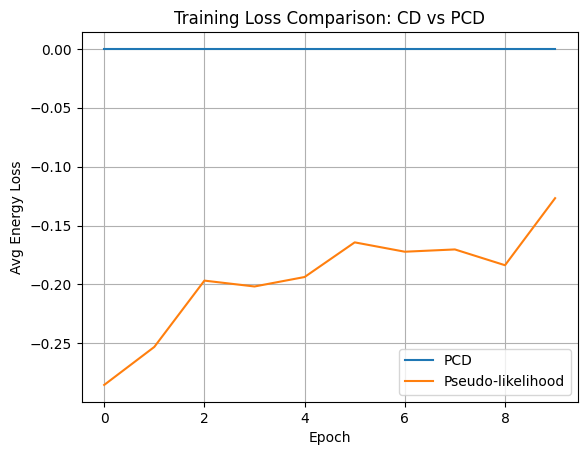

In [63]:
'''Hyperparameters here. 
num_gibbs_steps is an important addition, which determines 
how many gibbs steps are done for each sample in training
Increasing it increases training time linearly, unfortunately, 
and it is quite slow. '''
step_size = 0.01 # You can change this value for experiments 
l2_amount = 0.001 # L2 regularization amount
beta1 = 0.99  # First moment decay rate (momentum-like)
beta2 = 0.999  # Second moment decay rate
num_epochs = 10
batch_size = 20
num_gibbs_steps = 200
gibbs_heur_vectorize = True
track_grad= True
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)



# Print some graph statistics
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

bq.visualize_bm_bipartite_layout(G, node_labels, title="My Custom BM Layout (Bipartite Style)")


# Use the factory function
# model_cd = graph_to_bm(G, node_labels)
model_pcd = bq.graph_to_bm(G, node_labels)


# Sanity check
print("Sanity check:")
print("  dataset feature dim:", X_data.shape[1])
print("  model num_visible   :", model_pcd.num_visible)
print("  model num_hidden    :", model_pcd.num_hidden)

# optional: ensure W_vh orientation (V x H)
W_vv, W_hh, W_vh = model_pcd._get_masked_weights()
W_vv.zero_() # disables v-v connections
print("  W_vh shape (should be V x H):", tuple(W_vh.shape))
assert W_vh.shape == (model_pcd.num_visible, model_pcd.num_hidden)


# --- Training ---
optimizer_pcd = torch.optim.Adam(model_pcd.parameters(), lr=step_size, weight_decay=l2_amount, 
                                betas=(beta1, beta2))
pcd_losses, pll_values = bq.train_boltzmann_machine_pcd(model_pcd, data_loader, optimizer_pcd, num_epochs=num_epochs, k_steps=num_gibbs_steps, 
                                         batch_size=batch_size, step_size=step_size, 
                                         gibbs_heur_vectorize = gibbs_heur_vectorize, 
                                          track_grad=track_grad)

# check_fusion_strength(model_pcd, fused_pairs_remapped)
# --- Plot training loss ---
plt.plot(pcd_losses, label='PCD')
plt.plot(pll_values, label="Pseudo-likelihood")
plt.xlabel('Epoch')
plt.ylabel('Avg Energy Loss')
plt.title('Training Loss Comparison: CD vs PCD')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#--- Sampling & Visualization ---
num_gen_samples = 10
burn_in = 500
import importlib
importlib.reload(bq)

#need to find a way to speed up these sampling functions, so slow
print("\n--- Generating samples using Gibbs Sampling ---")
samples_pcd = bq.sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs', 
                                track_grad= True, gibbs_heur_vectorize= False)


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples from Gibbs Sampling (PCD)")


--- Generating samples using Gibbs Sampling ---
Running Gibbs sampler for 10 samples, 500 burn-in steps each... 🔥
  Gibbs sample 1/10
  Gibbs sample 1/10
  Gibbs sample 2/10
  Gibbs sample 2/10



--- Improving samples with Tabu Search ---

Displaying Tabu Search improved images... 🖼️


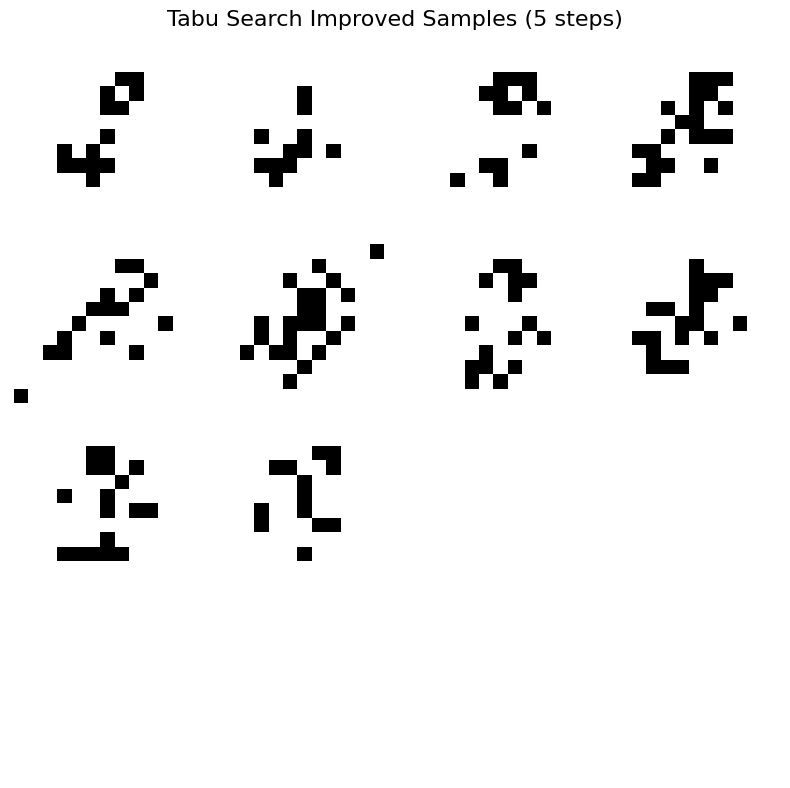

In [61]:
print("\n--- Improving samples with Tabu Search ---")
tabu_steps = 5
tabu_improved_samples = []
for i in range(samples_pcd.shape[0]):
    v_init = samples_pcd[i].unsqueeze(0)
    improved_v = bq.tabu_search_bm(model_pcd, v_init, steps=tabu_steps)
    tabu_improved_samples.append(improved_v)
tabu_improved_samples = torch.stack(tabu_improved_samples, dim=0)

print("\nDisplaying Tabu Search improved images... 🖼️")
plot_samples(tabu_improved_samples, f"Tabu Search Improved Samples ({tabu_steps} steps)")